# Finetuning QWEN-VL 7B for Speech Understanding

## 🌟 WHAT?

In this notebook, you will learn how to fine-tune [Qwen2-VL-7B](https://qwenlm.github.io/blog/qwen2-vl/) to understand speech using Hugging Face. Specifically, you will fine tune the model for the task of speech to text (a.k.a, automatic speech recognition).


💡 You can execute this Jupyter Notebook on a remote machine and then access and interact with it in your local web browser, leveraging the remote machine's computational resources.
- On remote: jupyter notebook --no-browser --port=8080
- On local: ssh -L 8080:localhost:8080 ntajbakhsh@workstation

🚨 **WARNING**: Please note that QWEN2-VL-7B is a relatively large model, requiring significant computational resources for fine-tuning. I recommend using either 2x A6000 or 1x A100 GPUs to ensure sufficient memory and processing power. While I haven't experimented with other GPUs, you're welcome to try alternative options. However, please be aware that other GPUs may not have enough memory to accommodate the model and optimizer states during training.

🚨 **WARNING**: Training transformers can be significantly more memory-efficient with Flash Attention (FA) compared to traditional attention mechanisms. However, FA support is currently limited to Nvidia's Ampere series of GPUs (A100, A6000, etc.) or better. If you're using an older GPU generation, please note that you'll need to disable FA to avoid error messages. Keep in mind that disabling FA may require using additional GPUs to compensate for the reduced memory efficiency.


# 1. Install Dependencies

Let’s start by installing the essential libraries we’ll need for fine-tuning! 🚀


In [ ]:
# !pip install -q "torch==2.4.1" "torchvision==0.19.1" "torchaudio==2.4.1"

In [ ]:
# !pip install -q datasets peft wandb accelerate matplotlib ipython librosa

We will also need to install an earlier version of *PyTorch*, as the latest version has an issue that currently prevents this notebook from running correctly. You can learn more about the issue [here](https://github.com/pytorch/pytorch/issues/138340) and consider updating to the latest version once it’s resolved.

In [ ]:
# !pip install -q torch==2.4.1+cu121 torchvision==0.19.1+cu121 torchaudio==2.4.1+cu121 --extra-index-url https://download.pytorch.org/whl/cu121

As you will see later, you need to fork HF transformers and qwen-vl-utils to make necessary changes to handle audio. So, you need to reinstall HF transformers and qwen-vl-utils from your own forks. For the reinstall to take effect, your fork of transformer must be ahead of what was installed above.

Transformers 4.47 is compatible with trl 0.18: https://github.com/huggingface/trl/blob/v0.18-release/requirements.txt

In [ ]:
# !pip uninstall -y -q trl
# !pip install -U -q "trl==0.17.0" # it says trl 0.18 requires higher transformers package, so step back to 0.17.0

In [ ]:
# !pip uninstall -y -q transformers
# !pip install -U -q "git+https://github.com/demirkeseny/transformers.git@qwen-audio-base"

In [ ]:
# !pip uninstall -y -q qwen-vl-utils
# !pip install -U -q "git+https://github.com/demirkeseny/Qwen2.5-VL.git@qvu-audio-base#subdirectory=qwen-vl-utils"


# 2. HF Login

Log in to Hugging Face to upload your fine-tuned model! 🗝️

You’ll need to authenticate with your Hugging Face account to save and share your model directly from this notebook.


In [ ]:
# !pip install huggingface_hub --upgrade

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
# !pip install -q matplotlib

In [ ]:
# from huggingface_hub import login
# # from google.colab import userdata
# # HF_TOKEN = userdata.get('HF_TOKEN') # add you token to colab secrets
# import os
# HF_TOKEN = os.environ['HF_TOKEN'] # export your HF_TOKEN first. You can add this to your ~/.bashrc.
# login(token=HF_TOKEN)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## Optional Settings for an Improved Jupyter Experience

In [ ]:
# from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
# from IPython.core.interactiveshell import InteractiveShell
# InteractiveShell.ast_node_interactivity = "all"
# %matplotlib inline

# 2. Understand Dataset 📁

Before we begin, take a moment to review this [link](https://huggingface.co/learn/audio-course/en/chapter1/introduction) and get familiar with the fundamentals of audio and speech data. This course covers the essentials of audio data, including the conversion of sound waves into digital formats, the role of sampling in analog-to-digital transformation, and the impact of sampling rates on audio quality. Additionally, you'll learn practical skills, such as loading and visualizing audio signals.

Next, you should load the [speechbrain/LargeScaleASR](https://huggingface.co/datasets/speechbrain/LargeScaleASR) dataset. This dataset contains 25,000 hours of diverse, transcribed English speech recognition data, available in three scalable sizes for research and commercial applications.

In [7]:
# TASK: load the dataset in the streaming mode to avoid a full dataset download!
# streaming mode allows to load only the moment we are processing
# downside is that the data is not stored meaning it will be reloaded every time to process
from datasets import load_dataset
import librosa
import matplotlib.pyplot as plt
import numpy as np
import io

speech_brain = load_dataset("speechbrain/LargeScaleASR", "small",streaming=True)

In [8]:
# TASK: use take and grab 1 sample from the streaming dataset, check its content, and visual the wave using librosa
# Take 1 sample from the train split
sample = next(iter(speech_brain['train'].take(1)))

Audio byte length show size of the raw audio data in memory. Each takes 2 bytes. So out of 27k samples, audio bytes is 54k.

In [ ]:
audio_bytes = sample['wav']['bytes']
print(f"Audio bytes length: {len(audio_bytes)}")

Audio bytes length: 547918


In [5]:
# get the audio data and sampling rate
audio_data, sampling_rate = librosa.load(io.BytesIO(audio_bytes), sr=None)

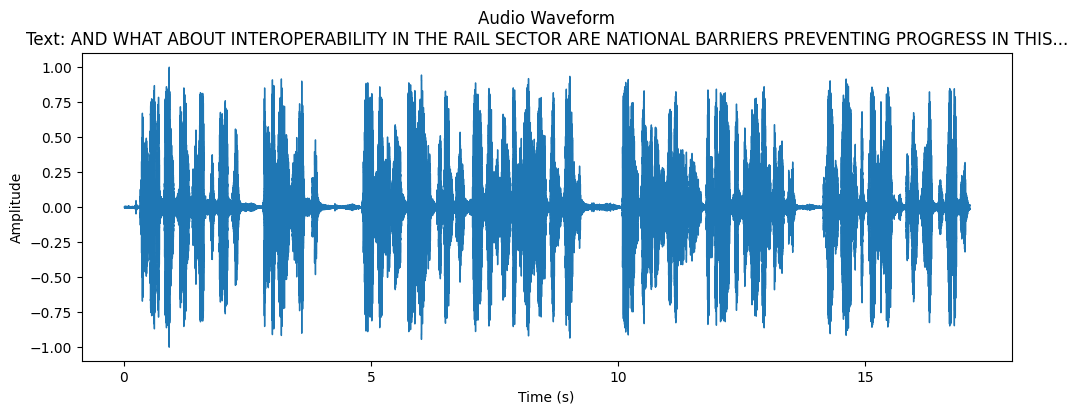

In [11]:
# Visualize the waveform
plt.figure(figsize=(12, 4))
librosa.display.waveshow(audio_data, sr=sampling_rate)
plt.title(f"Audio Waveform\nText: {sample['text'][:100]}...")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

In [10]:
# Display some basic audio statistics
duration = len(audio_data) / sampling_rate
print(f"\nAudio Statistics:")
print(f"  Duration: {duration:.2f} seconds")
print(f"  Min amplitude: {np.min(audio_data):.4f}")
print(f"  Max amplitude: {np.max(audio_data):.4f}")
print(f"  Mean amplitude: {np.mean(audio_data):.4f}")
print(f"  RMS: {np.sqrt(np.mean(audio_data**2)):.4f}")


Audio Statistics:
  Duration: 17.12 seconds
  Min amplitude: -0.9160
  Max amplitude: 1.0000
  Mean amplitude: 0.0000
  RMS: 0.1616


Now that we've covered the fundamentals, let's dive into using the OpenAI Whisper package to generate a sequence of audio tokens from a given audio signal. To do this effectively, make sure you understand the preprocessing step involved in generating the log mel spectrogram and how Whisper (the "turbo" variant) converts this intermediate representation into audio tokens.
Note that Whisper is an encoder-decoder model, but for our purposes, we'll only be using the encoder component to generate audio encodings.

In [ ]:
# TASK: Learn how to use whisper library to process an audio file from the dataset
# 30 sec batch size
# 10 stride -> makes 3000 frames
# 25 ms window
# 80 mel bins
# 2 x Conv1D with stride 2
# start shape: (b, 80, 3000)
# end shape: (b, 750, hidden_size) 
# GeLu
# PE

# Pipeline we need to build

The diagram below shows the dataflow of training our audio-text model. We need to build all the required building blocks in this chapter.

![xxxx](https://www.dropbox.com/scl/fi/9dwf41lsz8xbvpw3kw6gh/VLA.drawio.png?rlkey=ono3hwexwog1511slkhsqk2g9&st=jyfao0xj&raw=1)


Before we begin, let's set up a Hugging Face repository. This will allow us to store and share the assets we create during this project.

In [4]:
# TASK: Create a new repo on HF space and upload your new tokenizer
from huggingface_hub import create_repo, delete_repo
from transformers import Qwen2VLProcessor
from huggingface_hub import HfApi
api = HfApi()

/Users/yalimdemirkesen/Desktop/LLM/speech_recognition/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
repo_name = "mdmy/whisper_asr_finetuning"

In [8]:
# create_repo(repo_name)

## Step #1: Format Dataset

We need to create a conversation (user/assistant) for each training sample. These conversations will then be consumed by model's apply chat template.

In [ ]:
#TASK: format the data for the model by brining each training sample into the OpenAI conversation format

def format_data(sample):
    """
    Convert a training sample into OpenAI conversation format.
    Each sample contains audio data and its corresponding transcription.
    """
    # Extract the transcription text
    transcription = sample['text']
    
    # Create the conversation format
    conversation = [
        {
            "content":[{
                            "text": "You are an ASR model that transcribes speech to text. Avoid additional explanation unless absolutely necessary.",
                            "type": "text"
                        }],
            "role":"system"
        },
        {
            "content": [{
                    "audio": sample['wav']['bytes'],  # Raw audio bytes
                    "type": "audio"
                },
                {
                    "text": "Transcribe this speech into text.",
                    "type": "text",
                }
            ],
            "role": "user"
        },
        {
            "content": [
                {
                    "text": transcription,
                    "type": "text"
                }
            ],
            "role": "assistant",
        }
    ]
    
    return conversation

In [10]:
# TASK: apply the format_data function to the first sample of the dataset

# Get a sample from the dataset (reuse the sample we loaded earlier)
formatted_conversation = format_data(sample)

In [11]:
print("Formatted conversation:")
print(f"Number of messages: {len(formatted_conversation)}")
print("\n")

# System message
print("System message:")
print(f"Role: {formatted_conversation[0]['role']}")
print(f"Content types: {[item['type'] for item in formatted_conversation[0]['content']]}")
print(f"Text content: {formatted_conversation[0]['content'][0]['text'][:100]}...")
print("\n")

# User message
print("User message:")
print(f"Role: {formatted_conversation[1]['role']}")
print(f"Content types: {[item['type'] for item in formatted_conversation[1]['content']]}")
print(f"Audio data length: {len(formatted_conversation[1]['content'][0]['audio'])} bytes")
print(f"Prompt text: {formatted_conversation[1]['content'][1]['text']}")
print("\n")

# Assistant message
print("Assistant message:")
print(f"Role: {formatted_conversation[2]['role']}")
print(f"Content types: {[item['type'] for item in formatted_conversation[2]['content']]}")
print(f"Transcription preview: {formatted_conversation[2]['content'][0]['text'][:100]}...")


Formatted conversation:
Number of messages: 3


System message:
Role: system
Content types: ['text']
Text content: You are an ASR model that transcribes speech to text. Avoid additional explanation unless absolutely...


User message:
Role: user
Content types: ['audio', 'text']
Audio data length: 547918 bytes
Prompt text: Transcribe this speech into text.


Assistant message:
Role: assistant
Content types: ['text']
Transcription preview: AND WHAT ABOUT INTEROPERABILITY IN THE RAIL SECTOR ARE NATIONAL BARRIERS PREVENTING PROGRESS IN THIS...


The end result of this section is a dataset that is consumable by the chat template. It will expect the system, user and assistant roles assigned. The system is definition of the task, user shares the speech and assistant gives the answer in transcribed string. Here the format is dictionaries.

## Step #2: Create chat template

The Qwen2-vl chat template is specifically designed to handle visual inputs. To expand its capabilities, we'll need to modify the template to also support audio inputs. Download Qwen2-vl's processor and assign your new template to processor.chat_template. Your template should use special tokens to indicate the start and end of audio input. So, you need to further extend processor's tokenizer by adding special tokens for handling audio:
- <|audio_start|>: Start of audio input
- <|audio_pad|>: Audio padding token
- <|audio_end|>: End of audio input

Once done, save the processor on a designated location on the disk, which saves the tokenizer as a folder. Push the folder to your HF space using api.upload_folder. Do not specify repo_type.

In [12]:
processor = Qwen2VLProcessor.from_pretrained("Qwen/Qwen2-VL-7B-Instruct")
special_tokens_dict = {
    "additional_special_tokens": ["<|audio_start|>", "<|audio_pad|>", "<|audio_end|>"]
}
num_added = processor.tokenizer.add_special_tokens(special_tokens_dict)
print(f"Added {num_added} special tokens for audio")

Added 3 special tokens for audio


In [13]:
audio_token_ids = processor.tokenizer.convert_tokens_to_ids(["<|audio_start|>", "<|audio_pad|>", "<|audio_end|>"])
print(f"Audio token IDs: {audio_token_ids}")

Audio token IDs: [151657, 151658, 151659]


In [14]:
import textwrap

chat_template_w_audio = textwrap.dedent(r"""
{% set image_count = namespace(value=0) %}
{% set video_count = namespace(value=0) %}
{% set audio_count = namespace(value=0) %}
{% for message in messages %}
{% if loop.first and message['role'] != 'system' %}
<|im_start|>system
You are an ASR model that transcribes speech to text. Avoid additional explanation unless absolutely necessary.<|im_end|>
{% endif %}
<|im_start|>{{ message['role'] }}
{% if message['content'] is string %}
{{ message['content'] }}<|im_end|>
{% else %}
{% for content in message['content'] %}
    {# ----- Images ----- #}
    {% if content.get('type') == 'image' or 'image' in content or 'image_url' in content %}
        {% set image_count.value = image_count.value + 1 %}
        {% if add_vision_id %}Picture {{ image_count.value }}: {% endif %}
        <|vision_start|><|image_pad|><|vision_end|>
    {# ----- Videos ----- #}
    {% elif content.get('type') == 'video' or 'video' in content %}
        {% set video_count.value = video_count.value + 1 %}
        {% if add_vision_id %}Video {{ video_count.value }}: {% endif %}
        <|vision_start|><|video_pad|><|vision_end|>
    {# ----- Audio (ADDING THE AUDIO PORTION HERE) ----- #}
    {% elif content.get('type') in ['audio', 'input_audio'] or 'audio' in content %}
        {% set audio_count.value = audio_count.value + 1 %}
        {% if add_audio_id %}Audio {{ audio_count.value }}: {% endif %}
        <|audio_start|><|audio_pad|><|audio_end|>
    {# ----- Text ----- #}
    {% elif 'text' in content %}
        {{ content['text'] }}
    {% endif %}
{% endfor %}
<|im_end|>
{% endif %}
{% endfor %}
{% if add_generation_prompt %}
{% endif %}
""").strip()

In [15]:
chat_template_w_audio

"{% set image_count = namespace(value=0) %}\n{% set video_count = namespace(value=0) %}\n{% set audio_count = namespace(value=0) %}\n{% for message in messages %}\n{% if loop.first and message['role'] != 'system' %}\n<|im_start|>system\nYou are an ASR model that transcribes speech to text. Avoid additional explanation unless absolutely necessary.<|im_end|>\n{% endif %}\n<|im_start|>{{ message['role'] }}\n{% if message['content'] is string %}\n{{ message['content'] }}<|im_end|>\n{% else %}\n{% for content in message['content'] %}\n    {# ----- Images ----- #}\n    {% if content.get('type') == 'image' or 'image' in content or 'image_url' in content %}\n        {% set image_count.value = image_count.value + 1 %}\n        {% if add_vision_id %}Picture {{ image_count.value }}: {% endif %}\n        <|vision_start|><|image_pad|><|vision_end|>\n    {# ----- Videos ----- #}\n    {% elif content.get('type') == 'video' or 'video' in content %}\n        {% set video_count.value = video_count.value

In [16]:
print(processor.chat_template)

{% set image_count = namespace(value=0) %}{% set video_count = namespace(value=0) %}{% for message in messages %}{% if loop.first and message['role'] != 'system' %}<|im_start|>system
You are a helpful assistant.<|im_end|>
{% endif %}<|im_start|>{{ message['role'] }}
{% if message['content'] is string %}{{ message['content'] }}<|im_end|>
{% else %}{% for content in message['content'] %}{% if content['type'] == 'image' or 'image' in content or 'image_url' in content %}{% set image_count.value = image_count.value + 1 %}{% if add_vision_id %}Picture {{ image_count.value }}: {% endif %}<|vision_start|><|image_pad|><|vision_end|>{% elif content['type'] == 'video' or 'video' in content %}{% set video_count.value = video_count.value + 1 %}{% if add_vision_id %}Video {{ video_count.value }}: {% endif %}<|vision_start|><|video_pad|><|vision_end|>{% elif 'text' in content %}{{ content['text'] }}{% endif %}{% endfor %}<|im_end|>
{% endif %}{% endfor %}{% if add_generation_prompt %}<|im_start|>assi

In [17]:
processor.chat_template = chat_template_w_audio

In [17]:
# Save the processor with the new chat template and special tokens
local_save_path = "/Users/yalimdemirkesen/Desktop/LLM/speech_recognition/hf/qwen_w_audio_processor"
processor.save_pretrained(local_save_path)
print(f"Saved processor to: {local_save_path}")

Saved processor to: /Users/yalimdemirkesen/Desktop/LLM/speech_recognition/hf/qwen_w_audio_processor


In [18]:
# TASK: Push your new processor/tokenizer to your HF repo

api.upload_folder(
    folder_path="/Users/yalimdemirkesen/Desktop/LLM/speech_recognition/hf/",
    repo_id=repo_name,
    commit_message="Add audio-enabled Qwen processor/tokenizer"
)

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

Processing Files (1 / 1)                : 100%|██████████| 11.4MB / 11.4MB, 28.6MB/s  

Processing Files (1 / 1)                : 100%|██████████| 11.4MB / 11.4MB, 28.6MB/s  




Processing Files (1 / 1)                : 100%|██████████| 11.4MB / 11.4MB, 14.3MB/s  
New Data Upload                         : |          |  0.00B /  0.00B,  0.00B/s  
  ...en_w_audio_processor/tokenizer.json: 100%|██████████| 11.4MB / 11.4MB            
No files have been modified since last commit. Skipping to prevent empty commit.

Processing Files (1 / 1)                : 100%|██████████| 11.4MB / 11.4MB, 14.3MB/s  
New Data Upload                         : |          |  0.00B /  0.00B,  0.00B/s  
  ...en_w_audio_processor/tokenizer.json: 100%|██████████| 11.4MB / 11.4MB            
No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/mdmy/whisper_asr_finetuning/commit/832161633a7918d2519522d1f0cbaa2fcdf3f701', commit_message='Add audio-enabled Qwen processor/tokenizer', commit_description='', oid='832161633a7918d2519522d1f0cbaa2fcdf3f701', pr_url=None, repo_url=RepoUrl('https://huggingface.co/mdmy/whisper_asr_finetuning', endpoint='https://huggingface.co', repo_type='model', repo_id='mdmy/whisper_asr_finetuning'), pr_revision=None, pr_num=None)

In general, when increasing a tokenizer's vocabulary size, we need to resize the model's embedding and decoding layers. However, in this case, you don’t have to! Can you figure out why?

In [ ]:
# when adding new token, you also need to change the model size as well because 
# (1) the embeddings need to be learnt for the new tokens
# (2) you cannot have the LM head where we project a score to all the sequence if new tokens are in there.
# gec_tokenizer.add_special_tokens({'pad_token':'<pad>'})
# gec_model.resize_token_embeddings(len(gec_tokenizer))

# in this case I don't need to resize because
# (1) I am not using the decoder, so no LM Head resizing is needed. Decoder logits over vocab won't be calculated
# (2)<|audio_start|>, <|audio_pad|>, <|audio_end|> are indicators in the chat template. Data collator will take care of them.
# removes start and end. replaces pad with completing the tensor to 30 seconds by adding 0s in that 30 second window which represent silence.

# CHECK THE EMBEDDING TABLE FROM THE MODEL AND COMPARE AGAINST VOCAB SIZE

In [ ]:
# check the size of the vocab under tokenizer
len(processor.tokenizer)

151660

Now, let's load your processor from your HF repo and then apply the chat template and make sure it can properly handle a conversation with an audio input.

In [21]:
# TASK: load Qwen2VLProcessor from your repo, then use it to process a formatted response

from transformers import AutoProcessor

processor = AutoProcessor.from_pretrained(
    "mdmy/whisper_asr_finetuning",
    subfolder="qwen_w_audio_processor",
    trust_remote_code=True
)

print(f"Loaded processor from: {repo_name}")
print(f"Chat template includes audio support: {'audio' in processor.chat_template}")
print(f"Tokenizer vocabulary size: {len(processor.tokenizer)}")


Loaded processor from: mdmy/whisper_asr_finetuning
Chat template includes audio support: False
Tokenizer vocabulary size: 151660


In [22]:
# Apply the chat template to convert conversation to text
text_with_template = processor.apply_chat_template(
    formatted_conversation, 
    tokenize=False, 
    add_generation_prompt=True
)

print("Text with applied chat template:")
print(text_with_template)


Text with applied chat template:
<|im_start|>system
You are an ASR model that transcribes speech to text. Avoid additional explanation unless absolutely necessary.<|im_end|>
<|im_start|>user
Transcribe this speech into text.<|im_end|>
<|im_start|>assistant
AND WHAT ABOUT INTEROPERABILITY IN THE RAIL SECTOR ARE NATIONAL BARRIERS PREVENTING PROGRESS IN THIS AREA AS WELL OR IS THERE AN UNWILLINGNESS ON THE PART OF THE RAIL INDUSTRY TO EMBRACE THE CONCEPT OF INTEROPERABILITY<|im_end|>
<|im_start|>assistant



In [18]:
# Apply the chat template to convert conversation to text
text_with_template = processor.apply_chat_template(
    formatted_conversation, 
    tokenize=False, 
    add_generation_prompt=True
)

print("Text with applied chat template:")
print(text_with_template)


Text with applied chat template:
<|im_start|>system
        You are an ASR model that transcribes speech to text. Avoid additional explanation unless absolutely necessary.
<|im_end|>
<|im_start|>user
        <|audio_start|><|audio_pad|><|audio_end|>
        Transcribe this speech into text.
<|im_end|>
<|im_start|>assistant
        AND WHAT ABOUT INTEROPERABILITY IN THE RAIL SECTOR ARE NATIONAL BARRIERS PREVENTING PROGRESS IN THIS AREA AS WELL OR IS THERE AN UNWILLINGNESS ON THE PART OF THE RAIL INDUSTRY TO EMBRACE THE CONCEPT OF INTEROPERABILITY
<|im_end|>



In [22]:
# Now tokenize the formatted text (not the raw conversation)
inputs = processor(
    text=[text_with_template],
    images=None,
    videos=None,
    audios=audio_data,
    audio_sample_rate=sampling_rate,
    padding=True,
    return_tensors="pt",
)

print(f"Processed inputs keys: {inputs.keys()}")
print(f"Input IDs shape: {inputs['input_ids'].shape}")
print(f"Attention mask shape: {inputs['attention_mask'].shape}")

Processed inputs keys: dict_keys(['input_ids', 'attention_mask', 'audio_values', 'audio_splits', 'number_encoder_tokens', 'audio_length'])
Input IDs shape: torch.Size([1, 860])
Attention mask shape: torch.Size([1, 860])


In [23]:
# Let's examine the tokenized sequence
input_ids = inputs['input_ids'][0] 
print(f"Total tokens: {len(input_ids)}")

Total tokens: 860


In [25]:
# Find audio-related tokens
audio_start_id = processor.tokenizer.convert_tokens_to_ids("<|audio_start|>")
audio_pad_id = processor.tokenizer.convert_tokens_to_ids("<|audio_pad|>")
audio_end_id = processor.tokenizer.convert_tokens_to_ids("<|audio_end|>")

print(f"Audio start token ID: {audio_start_id}")
print(f"Audio pad token ID: {audio_pad_id}")  
print(f"Audio end token ID: {audio_end_id}")

Audio start token ID: 151657
Audio pad token ID: 151658
Audio end token ID: 151659


In [26]:
# Decode the full sequence to verify
decoded_text = processor.tokenizer.decode(inputs['input_ids'][0], skip_special_tokens=False)
print("Full decoded sequence:")
print(decoded_text)

Full decoded sequence:
<|im_start|>system
        You are an ASR model that transcribes speech to text. Avoid additional explanation unless absolutely necessary.
<|im_end|>
<|im_start|>user
        <|audio_start|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio_pad|><|audio

The end result is the tokenizable text format in one string. 

## Step #3: Load audio

To enable audio loading, you'll need to modify the vision_process.py file within the qwen-vl-utils package. Specifically, you should add a fetch_audio function, which will resemble the existing audio signal loading logic. This new function will be responsible for loading audio data from its byte-object representation into a NumPy array.

In [3]:
from qwen_vl_utils import vision_process
from qwen_vl_utils import process_vision_info

In [4]:
# downloaded correctly!
import inspect

print(inspect.getsource(vision_process.fetch_audio))

def fetch_audio(audio: Union[bytes, io.BytesIO, str]) -> tuple[np.array, int]:
    """
    Fetch and process audio data from various sources.
    
    Args:
        ele can be:
            - bytes: Raw audio bytes
            - BytesIO: Audio data as BytesIO object
            - str: File path to the audio file

    Returns:
        tuple[torch.Tensor, int]: Audio tensor and sampling rate
    """
    import librosa
    import numpy as np
    import soundfile as sf
    import librosa

    
    if isinstance(audio, bytes):
        # print("is instance of raw audio bytes")
        try:
            audio_data, sampling_rate = sf.read(io.BytesIO(audio))
        except Exception as e:
            raise ValueError(f"Failed to load audio from bytes: {e}")
    elif isinstance(audio, BytesIO):
        # print("is instance of BytesIO")
        try:
            audio.seek(0)  # Ensure we're at the beginning
            audio_data, sampling_rate = sf.read(audio)
        except Exception as e:
     

In [5]:
from qwen_vl_utils import vision_process
audio_bytes = sample['wav']['bytes']
audio_data, sampling_rate = vision_process.fetch_audio(audio_bytes)

NameError: name 'sample' is not defined

## Step #4: Extend the Processor

Qwen2-vl's processor tokenizes the chat template, repeats vision tokens for each image based on its size, and concatenates all vision inputs into a long tensor. To support audio, you'll need to modify this module to:
- Repeat the <|audio_pad|> token according to the length of each audio signal
- Concatenate all audio inputs into a long tensor
- Keep track of each audio input's length for later use in breaking the long input into individual audio encodings

To implement these changes, fork the transformers package and modify the processing_qwen2_vl.py file in src/transformers/models/qwen2_vl/.



In [21]:
# test with the whisper preprocessing token count

In [22]:
import math
import torch
import whisper

In [23]:
audio_bytes = sample['wav']['bytes']
y, sr_in = librosa.load(io.BytesIO(audio_bytes), sr=16000, mono=True)  # Whisper expects 16 kHz mono
duration = len(y) / 16000.0

In [24]:
encoder_steps = 750 * math.ceil(duration / 30.0)

In [18]:
print(f"Duration: {duration:.2f}s  |  Encoder steps: {encoder_steps}")

Duration: 17.12s  |  Encoder steps: 750


In [25]:
import torch
import torch.nn.functional as F
import numpy as np
from typing import Union, Optional
import librosa
import sys
import os
from src.utils import show_logmel, show_logmel_torch, exact_div, pad_and_split, convert_np_to_log_mel_spectrogram

In [26]:
# hard-coded audio hyperparameters
SAMPLE_RATE = 16000
N_FFT = 400 # fast fourier transform window size is 25ms, so there are 400 samples in 25ms
HOP_LENGTH = 160
CHUNK_LENGTH = 30
N_MELS = 80
N_SAMPLES = CHUNK_LENGTH * SAMPLE_RATE  # 480000 samples in a 30-second chunk
N_FRAMES = exact_div(N_SAMPLES, HOP_LENGTH)  # 3000 frames in a mel spectrogram input

N_SAMPLES_PER_TOKEN = HOP_LENGTH * 2  # the initial convolutions has stride 2
FRAMES_PER_SECOND = exact_div(SAMPLE_RATE, HOP_LENGTH)  # 10ms per audio frame
TOKENS_PER_SECOND = exact_div(SAMPLE_RATE, N_SAMPLES_PER_TOKEN)  # 20ms per audio token
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


In [27]:
print(audio_data.shape)
print(pad_and_split(SAMPLE_RATE, audio_data, DEVICE).shape)
print(convert_np_to_log_mel_spectrogram(SAMPLE_RATE, N_FFT, HOP_LENGTH, N_MELS, N_FRAMES, audio_data, DEVICE).shape)

(273920,)
torch.Size([1, 480000])
torch.Size([1, 80, 3000])


In [28]:
log_mel_spec = convert_np_to_log_mel_spectrogram(SAMPLE_RATE, N_FFT, HOP_LENGTH, N_MELS, N_FRAMES, audio_data, DEVICE)

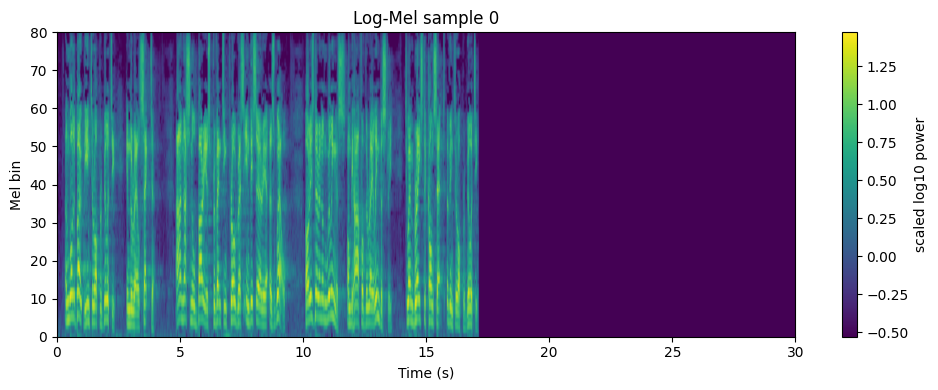

In [29]:
show_logmel_torch(log_mel_spec)

Append the same to the end and see how the batching works.

torch.Size([2, 80, 3000])


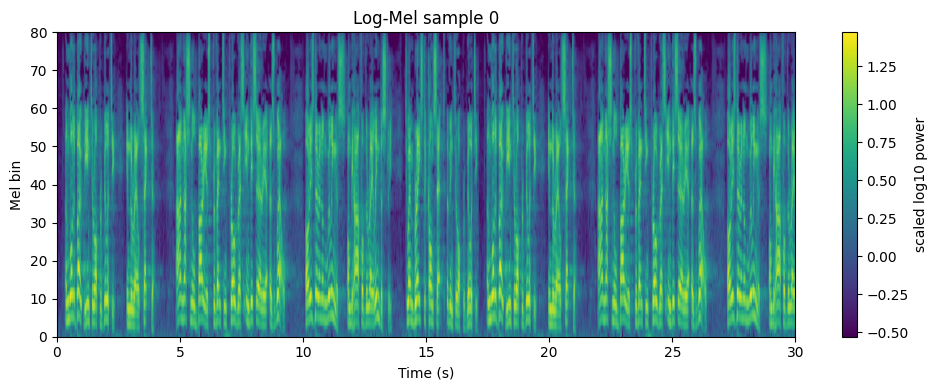

In [30]:
audio_data_doubled = np.concatenate([audio_data, audio_data])
double_log_mel_spec = convert_np_to_log_mel_spectrogram(SAMPLE_RATE, N_FFT, HOP_LENGTH, N_MELS, N_FRAMES, audio_data_doubled, DEVICE)
print(double_log_mel_spec.shape)
show_logmel_torch(double_log_mel_spec, idx=0)

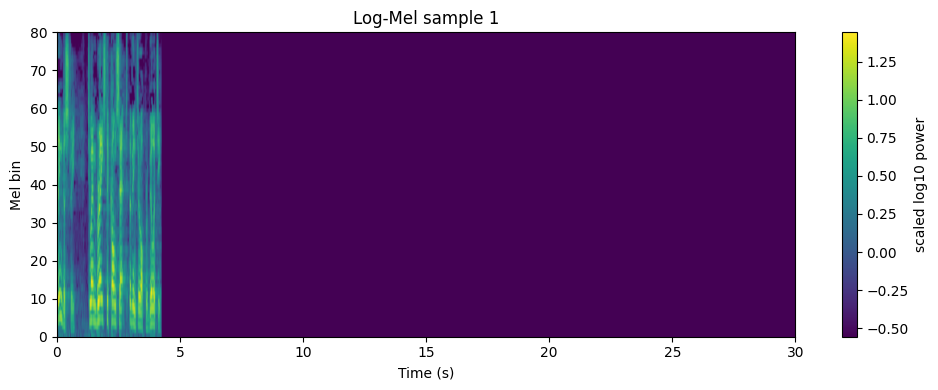

In [31]:
show_logmel_torch(double_log_mel_spec, idx=1)

In [29]:
from transformers.models.qwen2_vl.processing_qwen2_vl import Qwen2VLProcessor
import torch

processor = Qwen2VLProcessor.from_pretrained(
    "mdmy/whisper_asr_finetuning",
    subfolder="qwen_w_audio_processor",
    trust_remote_code=True
)

from datasets import load_dataset

speech_brain = load_dataset("speechbrain/LargeScaleASR", "small",streaming=True)

import librosa
import matplotlib.pyplot as plt
import numpy as np
import io


# Take 1 sample from the train split
sample = next(iter(speech_brain['train'].take(1)))


audio_bytes = sample['wav']['bytes']
audio_array, sampling_rate = librosa.load(io.BytesIO(audio_bytes), sr=16000, mono=True)

formatted_conversation = format_data(sample)

text_with_template = processor.apply_chat_template(
    formatted_conversation, 
    tokenize=False, 
    add_generation_prompt=True
)

In [24]:
print(text_with_template)

<|im_start|>system
        You are an ASR model that transcribes speech to text. Avoid additional explanation unless absolutely necessary.
<|im_end|>
<|im_start|>user
        <|audio_start|><|audio_pad|><|audio_end|>
        Transcribe this speech into text.
<|im_end|>
<|im_start|>assistant
        AND WHAT ABOUT INTEROPERABILITY IN THE RAIL SECTOR ARE NATIONAL BARRIERS PREVENTING PROGRESS IN THIS AREA AS WELL OR IS THERE AN UNWILLINGNESS ON THE PART OF THE RAIL INDUSTRY TO EMBRACE THE CONCEPT OF INTEROPERABILITY
<|im_end|>



In [31]:
audio_array.shape[0]/sampling_rate

17.12

In [32]:
batch = processor(
    text=text_with_template,
    audios=audio_array,
    audio_sample_rate=sampling_rate,
    return_tensors="pt"
)

In [33]:
batch.input_ids.shape

torch.Size([1, 860])

In [34]:
batch

{'input_ids': tensor([[151644,   8948,    198,    286,   1446,    525,    458,   5752,     49,
           1614,    429,   1356,  55136,   8806,    311,   1467,     13,  34006,
           5107,  16148,   7241,  10875,   5871,    624, 151645,    198, 151644,
            872,    198,    260, 151657, 151658, 151658, 151658, 151658, 151658,
         151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658,
         151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658,
         151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658,
         151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658,
         151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658,
         151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658,
         151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658,
         151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658,
         15165

In [23]:
batch.input_ids[0]

tensor([151644,   8948,    198,    286,   1446,    525,    458,   5752,     49,
          1614,    429,   1356,  55136,   8806,    311,   1467,     13,  34006,
          5107,  16148,   7241,  10875,   5871,    624, 151645,    198, 151644,
           872,    198,    260, 151657, 151658, 151658, 151658, 151658, 151658,
        151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658,
        151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658,
        151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658,
        151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658,
        151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658,
        151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658,
        151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658,
        151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658, 151658,
        151658, 151658, 151658, 151658, 

In [21]:
(batch.input_ids[0] == 151658).sum().item()

856

In [37]:
processor.tokenizer.decode([151658])

'<|audio_pad|>'

In [38]:
batch.keys()

dict_keys(['input_ids', 'attention_mask', 'audio_values', 'audio_splits', 'number_encoder_tokens', 'audio_length'])

In [39]:
batch.audio_length

17.12

## Step #5: Create the Model

To create your model, follow the structure of Qwen2VLForConditionalGeneration. Specifically:
- Define a class that inherits from a PreTrained class, which simplifies model initialization, loading, and device mapping.
- Incorporate the audio encoder and audio projection layers into your model.

Implement your model class in src/transformers/models/qwen2_vl/modeling_qwen2_vl.py within your forked transformers repository.
Defining Model Configuration Classes

Additionally, define your model configuration classes in src/transformers/models/qwen2_vl/configuration_qwen2_vl.py. This will ensure your model is properly configured and aligned with the Qwen2VL architecture.

In [ ]:
# HOW DOES THE DEVICE MAPPING WORK?
# manual implementation

# # load the model
# m = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype="bfloat16")

# # build memory budgets
# from accelerate import get_balanced_memory
# max_mem = get_balanced_memory(
#     m, dtype="bfloat16",
#     no_split_module_classes=["Qwen2VLDecoderLayer","Qwen2VLVisionBlock"]
# )
# # or: max_mem = {0:"22GiB", 1:"22GiB", "cpu":"120GiB"}

# # infer the device map
# from accelerate import infer_auto_device_map
# device_map = infer_auto_device_map(
#     m, max_memory=max_mem, dtype="bfloat16",
#     no_split_module_classes=["Qwen2VLDecoderLayer","Qwen2VLVisionBlock"]
# )

# m = AutoModelForCausalLM.from_pretrained(
#     MODEL_ID, torch_dtype="bfloat16",
#     device_map=device_map, offload_folder="offload_dir"
# )
# # m.hf_device_map shows actual placements

In [4]:
from transformers import AutoProcessor
import torch
from transformers import Qwen2VLConfig  
from transformers import Qwen2VLForConditionalGenerationWithAudio 
from transformers import Qwen2VLAudioConfig

/Users/yalimdemirkesen/Desktop/LLM/speech_recognition/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32

In [6]:
BASE_ID = "Qwen/Qwen2-VL-7B-Instruct"

In [27]:
import textwrap

chat_template_w_audio = textwrap.dedent(r"""
{% set image_count = namespace(value=0) %}
{% set video_count = namespace(value=0) %}
{% set audio_count = namespace(value=0) %}
{% for message in messages %}
{% if loop.first and message['role'] != 'system' %}
<|im_start|>system
You are an ASR model that transcribes speech to text. Avoid additional explanation unless absolutely necessary.<|im_end|>
{% endif %}
<|im_start|>{{ message['role'] }}
{% if message['content'] is string %}
{{ message['content'] }}<|im_end|>
{% else %}
{% for content in message['content'] %}
    {# ----- Images ----- #}
    {% if content.get('type') == 'image' or 'image' in content or 'image_url' in content %}
        {% set image_count.value = image_count.value + 1 %}
        {% if add_vision_id %}Picture {{ image_count.value }}: {% endif %}
        <|vision_start|><|image_pad|><|vision_end|>
    {# ----- Videos ----- #}
    {% elif content.get('type') == 'video' or 'video' in content %}
        {% set video_count.value = video_count.value + 1 %}
        {% if add_vision_id %}Video {{ video_count.value }}: {% endif %}
        <|vision_start|><|video_pad|><|vision_end|>
    {# ----- Audio (ADDING THE AUDIO PORTION HERE) ----- #}
    {% elif content.get('type') in ['audio', 'input_audio'] or 'audio' in content %}
        {% set audio_count.value = audio_count.value + 1 %}
        {% if add_audio_id %}Audio {{ audio_count.value }}: {% endif %}
        <|audio_start|><|audio_pad|><|audio_end|>
    {# ----- Text ----- #}
    {% elif 'text' in content %}
        {{ content['text'] }}
    {% endif %}
{% endfor %}
<|im_end|>
{% endif %}
{% endfor %}
{% if add_generation_prompt %}
{% endif %}
""").strip()

# default_processor = AutoProcessor.from_pretrained(
#     "mdmy/whisper_asr_finetuning",
#     subfolder="qwen_w_audio_processor",
#     trust_remote_code=True
# )

# vision_tokens = [
#     "<|im_start|>", "<|im_end|>",
#     "<|object_ref_start|>", "<|object_ref_end|>",
#     "<|box_start|>", "<|box_end|>",
#     "<|quad_start|>", "<|quad_end|>",
#     "<|vision_start|>", "<|vision_end|>", "<|vision_pad|>",
#     "<|image_pad|>", "<|video_pad|>",
# ]
# audio_tokens = ["<|audio_start|>", "<|audio_pad|>", "<|audio_end|>"]
# merged = vision_tokens + audio_tokens
# default_processor.tokenizer.add_special_tokens({"additional_special_tokens": merged})

vision_tokens = [
    "<|im_start|>", "<|im_end|>",
    "<|object_ref_start|>", "<|object_ref_end|>",
    "<|box_start|>", "<|box_end|>",
    "<|quad_start|>", "<|quad_end|>",
    "<|vision_start|>", "<|vision_end|>", "<|vision_pad|>",
    "<|image_pad|>", "<|video_pad|>",
]
audio_tokens = ["<|audio_start|>", "<|audio_pad|>", "<|audio_end|>"]

processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-7B-Instruct", trust_remote_code=True)
merged = []
for t in (vision_tokens + audio_tokens):
    if t not in merged:
        merged.append(t)

processor.tokenizer.add_special_tokens({"additional_special_tokens": merged})
# optional sanity checks
assert set(vision_tokens).issubset(set(processor.tokenizer.additional_special_tokens))
assert set(audio_tokens).issubset(set(processor.tokenizer.additional_special_tokens))

# keep your audio chat template (but ensure assistant start exists)
processor.tokenizer.chat_template = chat_template_w_audio

In [ ]:
processor.tokenizer.encode("<|audio_pad|>")

[151658]

: 

In [4]:
processor = AutoProcessor.from_pretrained(
    "mdmy/whisper_asr_finetuning",
    subfolder="qwen_w_audio_processor",
    trust_remote_code=True
)

tok = processor.tokenizer

audio_pad = "<|audio_pad|>"
audio_start = "<|audio_start|>"
audio_end = "<|audio_end|>"

audio_pad_id = tok.convert_tokens_to_ids(audio_pad)
audio_start_id = tok.convert_tokens_to_ids(audio_start)
audio_end_id = tok.convert_tokens_to_ids(audio_end)

print(audio_start_id, audio_pad_id, audio_end_id)

151657 151658 151659


In [8]:
audio_cfg = Qwen2VLAudioConfig(
        # sample_rate=16000,
        # n_fft=400,
        # hop_length=160,
        # n_mels=80,                  
        # n_frames=3000,              # 30s @ 100 fps; your encoder can pad/trim to this
        # d_model=1280,               # Whisper-large-v3 d_model
        # proj_out=8192,              # LM hidden size (Qwen2-VL 7B)
        # max_position_embeddings=750,
        # token_id=audio_pad_id,
        # start_token_id=audio_start_id,
        # end_token_id=audio_end_id,
    )

In [6]:
audio_cfg

Qwen2VLAudioConfig {
  "_name_or_path": "/Users/yalimdemirkesen/Desktop/LLM/speech_recognition/transformers/src/transformers/models/qwen2_vl/configuration_qwen2_vl.py",
  "d_model": 1280,
  "encoder_heads": 8,
  "encoder_layers": 4,
  "end_token_id": 151659,
  "hidden_size": 512,
  "hop_length": 160,
  "max_seconds": 60,
  "model_type": "qwen2_vl",
  "n_fft": 400,
  "n_mels": 128,
  "pretrained_model_name": "openai/whisper-large-v3-turbo",
  "proj_out": 8192,
  "sample_rate": 16000,
  "start_token_id": 151657,
  "token_id": 151658,
  "transformers_version": "4.47.0"
}

In [9]:
cfg = Qwen2VLConfig.from_pretrained(BASE_ID, trust_remote_code=True)
cfg.use_audio = True
cfg.audio_config = audio_cfg

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


In [10]:
model = Qwen2VLForConditionalGenerationWithAudio.from_pretrained(
    BASE_ID,
    config=cfg,
    torch_dtype=DTYPE,
    low_cpu_mem_usage=True,
    ignore_mismatched_sizes=True,   # audio heads are new
    trust_remote_code=True,
    device_map=None,                # single device for the test
).to(DEVICE)
model.eval()

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
`Qwen2VLRotaryEmbedding` can now be fully parameterized by passing the model config through the `config` argument. All other arguments will be removed in v4.46
Loading checkpoint shards: 100%|██████████| 5/5 [00:22<00:00,  4.56s/it]
Some weights of Qwen2VLForConditionalGenerationWithAudio were not initialized from the model checkpoint at Qwen/Qwen2-VL-7B-Instruct and are newly initialized: ['audio_module.audio_projection.weight', 'audio_module.whisper_encoder.conv1.bias', 'audio_module.whisper_encoder.conv1.weight', 'audio_module.whisper_encoder.conv2.bias', 'audio_module.whisper_encoder.conv2.weight', 'audio_module.whisper_encoder.embed_positions.weight', 'audio_module.whisper_encoder.layer_norm.bias', 'audio_module.whisper_encoder.layer_norm.weight', 'audio_module.whisper_encoder.layers.0.fc1.bias', 'audio_module.whisper_encoder.layers.0.fc1.weight', 'audio_module.whisper_encoder.l

Qwen2VLForConditionalGenerationWithAudio(
  (visual): Qwen2VisionTransformerPretrainedModel(
    (patch_embed): PatchEmbed(
      (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
    )
    (rotary_pos_emb): VisionRotaryEmbedding()
    (blocks): ModuleList(
      (0-31): 32 x Qwen2VLVisionBlock(
        (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (attn): VisionSdpaAttention(
          (qkv): Linear(in_features=1280, out_features=3840, bias=True)
          (proj): Linear(in_features=1280, out_features=1280, bias=True)
        )
        (mlp): VisionMlp(
          (fc1): Linear(in_features=1280, out_features=5120, bias=True)
          (act): QuickGELUActivation()
          (fc2): Linear(in_features=5120, out_features=1280, bias=True)
        )
      )
    )
    (merger): PatchMerger(
      (ln_q): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
      (

In [9]:
print(f"encoder: \n {model.audio_module.whisper_encoder}")

encoder: 
 WhisperEncoder(
  (conv1): Conv1d(128, 1280, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(1280, 1280, kernel_size=(3,), stride=(2,), padding=(1,))
  (embed_positions): Embedding(1500, 1280)
  (layers): ModuleList(
    (0-31): 32 x WhisperEncoderLayer(
      (self_attn): WhisperSdpaAttention(
        (k_proj): Linear(in_features=1280, out_features=1280, bias=False)
        (v_proj): Linear(in_features=1280, out_features=1280, bias=True)
        (q_proj): Linear(in_features=1280, out_features=1280, bias=True)
        (out_proj): Linear(in_features=1280, out_features=1280, bias=True)
      )
      (self_attn_layer_norm): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
      (activation_fn): GELUActivation()
      (fc1): Linear(in_features=1280, out_features=5120, bias=True)
      (fc2): Linear(in_features=5120, out_features=1280, bias=True)
      (final_layer_norm): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
    )
  )
  (layer_norm): LayerNo

In [10]:
print(f"config: \n {model.config.audio_config}")

config: 
 Qwen2VLAudioConfig {
  "_name_or_path": "/Users/yalimdemirkesen/Desktop/LLM/speech_recognition/transformers/src/transformers/models/qwen2_vl/configuration_qwen2_vl.py",
  "d_model": 1280,
  "encoder_heads": 8,
  "encoder_layers": 4,
  "end_token_id": 151659,
  "hidden_size": 512,
  "hop_length": 160,
  "max_seconds": 60,
  "model_type": "qwen2_vl",
  "n_fft": 400,
  "n_mels": 128,
  "pretrained_model_name": "openai/whisper-large-v3-turbo",
  "proj_out": 8192,
  "sample_rate": 16000,
  "start_token_id": 151658,
  "token_id": 151657,
  "transformers_version": "4.47.0"
}



In [11]:
model.config.audio_config.pretrained_model_name

'openai/whisper-large-v3-turbo'

In [12]:
model.audio_module.whisper_encoder

WhisperEncoder(
  (conv1): Conv1d(128, 1280, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(1280, 1280, kernel_size=(3,), stride=(2,), padding=(1,))
  (embed_positions): Embedding(1500, 1280)
  (layers): ModuleList(
    (0-31): 32 x WhisperEncoderLayer(
      (self_attn): WhisperSdpaAttention(
        (k_proj): Linear(in_features=1280, out_features=1280, bias=False)
        (v_proj): Linear(in_features=1280, out_features=1280, bias=True)
        (q_proj): Linear(in_features=1280, out_features=1280, bias=True)
        (out_proj): Linear(in_features=1280, out_features=1280, bias=True)
      )
      (self_attn_layer_norm): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
      (activation_fn): GELUActivation()
      (fc1): Linear(in_features=1280, out_features=5120, bias=True)
      (fc2): Linear(in_features=5120, out_features=1280, bias=True)
      (final_layer_norm): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
    )
  )
  (layer_norm): LayerNorm((1280,),

In [13]:
from transformers import WhisperModel, AutoModelForSpeechSeq2Seq

ref = WhisperModel.from_pretrained(
            model.config.audio_config.pretrained_model_name,
            local_files_only=False
        ).to(device=DEVICE, dtype=DTYPE)

ref_enc = ref.encoder

In [14]:
ref_enc

WhisperEncoder(
  (conv1): Conv1d(128, 1280, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(1280, 1280, kernel_size=(3,), stride=(2,), padding=(1,))
  (embed_positions): Embedding(1500, 1280)
  (layers): ModuleList(
    (0-31): 32 x WhisperEncoderLayer(
      (self_attn): WhisperSdpaAttention(
        (k_proj): Linear(in_features=1280, out_features=1280, bias=False)
        (v_proj): Linear(in_features=1280, out_features=1280, bias=True)
        (q_proj): Linear(in_features=1280, out_features=1280, bias=True)
        (out_proj): Linear(in_features=1280, out_features=1280, bias=True)
      )
      (self_attn_layer_norm): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
      (activation_fn): GELUActivation()
      (fc1): Linear(in_features=1280, out_features=5120, bias=True)
      (fc2): Linear(in_features=5120, out_features=1280, bias=True)
      (final_layer_norm): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
    )
  )
  (layer_norm): LayerNorm((1280,),

In [15]:
def stats(t: torch.Tensor):
    t = t.detach().float().cpu()
    return f"shape={tuple(t.shape)} mean={t.mean():.6f} std={t.std():.6f}"

In [16]:
keys = [
    "conv1.weight",
    "conv2.weight",
    "layer_norm.weight",
    "layers.0.self_attn.q_proj.weight",
    "layers.0.self_attn.k_proj.weight",
    "layers.0.self_attn.v_proj.weight",
]

In [17]:
atol, rtol = 1e-5, 1e-4

In [18]:
# CHECK THE WEIGHTS OF THE ENCODER LAYERS ARE THE SAME
my_enc = model.audio_module.whisper_encoder

ref_id = model.config.audio_config.pretrained_model_name
ref_enc = WhisperModel.from_pretrained(ref_id).encoder

for k in keys:
    if k not in my_enc.state_dict() or k not in ref_enc.state_dict():
        print(f"[skip] {k} not found in one of the encoders")
        continue

    a = my_enc.state_dict()[k].detach().float().cpu()
    b = ref_enc.state_dict()[k].detach().float().cpu()

    same_shape = a.shape == b.shape
    close = torch.allclose(a, b, atol=atol, rtol=rtol) if same_shape else False
    # allclose wil check on element level if the values are the same
    # |input_i - other_i| <= atol + rtol * |other_i|

    print(f"\n[{k}]")
    print(" my :", stats(a))
    print(" ref:", stats(b))
    print(f" same_shape={same_shape}  allclose(atol={atol}, rtol={rtol}) -> {close}")


[conv1.weight]
 my : shape=(1280, 128, 3) mean=0.000018 std=0.017555
 ref: shape=(1280, 128, 3) mean=0.000018 std=0.017555
 same_shape=True  allclose(atol=1e-05, rtol=0.0001) -> True

[conv2.weight]
 my : shape=(1280, 1280, 3) mean=-0.003525 std=0.013258
 ref: shape=(1280, 1280, 3) mean=-0.003525 std=0.013258
 same_shape=True  allclose(atol=1e-05, rtol=0.0001) -> True

[layer_norm.weight]
 my : shape=(1280,) mean=0.403009 std=0.042042
 ref: shape=(1280,) mean=0.403009 std=0.042042
 same_shape=True  allclose(atol=1e-05, rtol=0.0001) -> True

[layers.0.self_attn.q_proj.weight]
 my : shape=(1280, 1280) mean=-0.000116 std=0.021686
 ref: shape=(1280, 1280) mean=-0.000116 std=0.021686
 same_shape=True  allclose(atol=1e-05, rtol=0.0001) -> True

[layers.0.self_attn.k_proj.weight]
 my : shape=(1280, 1280) mean=0.000027 std=0.020687
 ref: shape=(1280, 1280) mean=0.000027 std=0.020687
 same_shape=True  allclose(atol=1e-05, rtol=0.0001) -> True

[layers.0.self_attn.v_proj.weight]
 my : shape=(12

In [19]:
# CHECK IF THE AUDIO LAYERS ARE FROZEN OR NOT
# audio projection is not frozen, but the encoder is frozen
proj = model.audio_module.audio_projection
print(any(p.requires_grad for p in proj.parameters()))
print(any(p.requires_grad for p in model.audio_module.whisper_encoder.parameters()))

True
False


In [20]:
# CHECK IF THE AUDIO ENCODER IS FROZEN AND ITS TRAINING MODE
# expectation is that encoder is frozen and not in training mode due to eval() call
enc = model.audio_module.whisper_encoder
print(all(p.requires_grad is False for p in enc.parameters()), enc.training)

True False


In [13]:
def format_data(sample):
    """
    Convert a training sample into OpenAI conversation format.
    Each sample contains audio data and its corresponding transcription.
    """
    # Extract the transcription text
    transcription = sample['text']
    
    # Create the conversation format
    conversation = [
        {
            "content":[{
                            "text": "You are an ASR model that transcribes speech to text. Avoid additional explanation unless absolutely necessary.",
                            "type": "text"
                        }],
            "role":"system"
        },
        {
            "content": [{
                    "audio": sample['wav']['bytes'],  # Raw audio bytes
                    "type": "audio"
                },
                {
                    "text": "Transcribe this speech into text.",
                    "type": "text",
                }
            ],
            "role": "user"
        },
        {
            "content": [
                {
                    "text": transcription,
                    "type": "text"
                }
            ],
            "role": "assistant",
        }
    ]
    
    return conversation

In [14]:
# TEST THE EMBEDDING REPLACEMENT FOR AUDIO PADS
from datasets import load_dataset 
import librosa
import io  

speech_brain = load_dataset("speechbrain/LargeScaleASR", "small",streaming=True) 

sample = next(iter(speech_brain['train'].take(1))) 

audio_bytes = sample['wav']['bytes'] 
audio_array, sampling_rate = librosa.load(io.BytesIO(audio_bytes), sr=16000, mono=True) 

formatted_conversation = format_data(sample) 
text_with_template = processor.apply_chat_template(formatted_conversation, 
                                                   tokenize=False, 
                                                   add_generation_prompt=True) 

batch = processor(text=text_with_template, 
                  audios=audio_array, 
                  audio_sample_rate=sampling_rate, 
                  return_tensors="pt")

In [15]:
input_ids = batch["input_ids"].to(DEVICE)
attention_mask = batch["attention_mask"].to(DEVICE)

In [16]:
audio_vals = batch["audio_values"]
audio_vals = audio_vals.unsqueeze(0)
audio_vals.shape

torch.Size([1, 273920])

In [17]:
audio_values = audio_vals.to(DEVICE).to(torch.float32)

In [18]:
audio_pad_token_cnt = int(batch["number_encoder_tokens"].item())
audio_pad_token_cnt

856

In [16]:
# PROVE THAT FORWARD PASS WORKS WHEN AUDIO IS INSERTED.
# expectation is that it gives batch, number of tokens, vocab size for logits. 
model.eval()
with torch.inference_mode():
    out = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        audio_values=audio_values,   # raw waveform → internal log-mel + Whisper encoder
        use_cache=True,
        return_dict=True,
    )    

In [18]:
print("logits shape:", tuple(out.logits.shape))

logits shape: (1, 966, 152064)


In [19]:
B, L_via_ids = input_ids.shape
V_cfg = model.config.vocab_size

print("B expected:", B)
print("L from input_ids:", L_via_ids)
print("V from config:", V_cfg)
print("logits shape:", tuple(out.logits.shape))

B expected: 1
L from input_ids: 966
V from config: 152064
logits shape: (1, 966, 152064)


In [20]:
out.logits

tensor([[[ 2.7880,  3.3393,  1.9852,  ..., -2.7537, -2.7537, -2.7536],
         [ 5.8148,  4.9114,  1.8072,  ..., -3.9374, -3.9381, -3.9391],
         [ 2.5039,  3.9486,  9.2036,  ..., -1.8746, -1.8747, -1.8746],
         ...,
         [ 1.7605,  4.1683,  3.7897,  ..., -2.1997, -2.1999, -2.1996],
         [ 2.5630, -2.9042,  5.8359,  ..., -2.6793, -2.6786, -2.6790],
         [ 0.1618, -0.2873,  5.8833,  ...,  0.1464,  0.1474,  0.1462]]])

In [21]:
out.logits.shape

torch.Size([1, 966, 152064])

In [22]:
# get the logits for the last token
logits = out.logits
next_token_logits = logits[:, -1, :] 
from torch.nn.functional import softmax
probs = softmax(next_token_logits, dim=-1)
next_token_id = probs.argmax(dim=-1)
next_token_id

tensor([151644])

In [ ]:
# CHECK WHETHER MASKING IS CORRECTLY APPLIED
AUDIO_PAD = tok.convert_tokens_to_ids("<|audio_pad|>")
AUDIO_START = tok.convert_tokens_to_ids("<|audio_start|>")
AUDIO_END = tok.convert_tokens_to_ids("<|audio_end|>")
IM_START = tok.convert_tokens_to_ids("<|im_start|>") if "<|im_start|>" in tok.get_vocab() else None
IM_END   = tok.convert_tokens_to_ids("<|im_end|>")   if "<|im_end|>"   in tok.get_vocab() else None
IMG_ID   = getattr(model.config, "image_token_id", None)
VID_ID   = getattr(model.config, "video_token_id", None)
VSTART   = getattr(model.config, "vision_start_token_id", None)
VEND     = getattr(model.config, "vision_end_token_id", None)

IGNORE_IDS = {x for x in [AUDIO_PAD, AUDIO_START, AUDIO_END, IM_START, IM_END, IMG_ID, VID_ID, VSTART, VEND] if x is not None}

In [ ]:
IGNORE_IDS

{151644, 151645, 151652, 151653, 151655, 151656, 151657, 151658, 151659}

In [37]:
labels = input_ids.clone()
for tid in IGNORE_IDS:
    labels[input_ids == tid] = -100

In [38]:
labels

tensor([[-100, 8948,  198,  ...,  198, -100,  198]])

In [39]:
logits = out.logits.float()               # (B, L, V), unnormalized

# ---- compute cross-entropy exactly like HF trainer does (shifted) ----
shift_logits = logits[:, :-1, :].contiguous()     # (B, L-1, V)
shift_labels = labels[:, 1:].contiguous()         # (B, L-1)

B, Tm1, V = shift_logits.shape
flat_logits = shift_logits.view(-1, V)            # ((B*(L-1)), V)
flat_labels = shift_labels.view(-1) 

In [41]:
from torch.nn.functional import cross_entropy

keep = flat_labels != -100
kept_logits = flat_logits[keep]                   # (N, V)
kept_labels = flat_labels[keep]                   # (N,)
loss_masked = cross_entropy(kept_logits, kept_labels)
print(f"[masked] CE loss over {kept_labels.numel()} tokens: {loss_masked.item():.6f}")

[masked] CE loss over 102 tokens: 3.026353


In [42]:
labels_unmasked = input_ids.clone()
shift_labels_um = labels_unmasked[:, 1:].contiguous().view(-1)
loss_unmasked = cross_entropy(flat_logits, shift_labels_um)
print(f"[unmasked] CE loss over {(B*(Tm1))} tokens: {loss_unmasked.item():.6f}")

[unmasked] CE loss over 1609 tokens: 14.064416


In [ ]:
# AUDIO MASKING SEEMS WORKING BECAUSE THE LOSS IS MUCH HIGHER WHEN WE DO NOT MASK THE AUDIO TOKENS

In [ ]:
# TODO: NEXT STEP IS TO CONVERT >30 SEC AUDIOS INTO MULTIPLE OUTPUTS IN A LIST
# all_chunks = []  # list of (C_i, n_mels, n_frames) where i is the chunk index
# for a in arr_list:
#     chunks = self._pad_and_split(self.sample_rate, a, device)  
#     # _pad_and_split already supports multi chunk with right padding for <30 sec chunks
#     mel = self._log_mel_chunks(
#         chunks,
#         n_fft=self.n_fft,
#         hop_length=self.hop_length,
#         n_mels=self.n_mels,
#         n_frames=self.n_frames,
#         sr=self.sample_rate,
#     )  # (C_i, n_mels, n_frames)
#     all_chunks.append(mel)

# Initialize & Push Model

Let's instantiate our model using the weights from the Qwen2VL checkpoint, noting that this will randomly initialize the audio encoder and audio projection layers. We'll then load the pre-trained weights from Whisper Turbo into our audio encoder, replacing the random initialization. After loading the Whisper Turbo weights, save the model, which now only has the audio projection layer randomly initialized. Finally, push the saved checkpoint to your Hugging Face repository. Now, both model and tokenizer should be there.

In [35]:
# TASK: Load the Qwen2VL checkpoint into your model, load whisper turbo, save and push to your repo -  Now, the model and tokenizer should both be there.
# save the model with the new audio config
model_save_path = "/Users/yalimdemirkesen/Desktop/LLM/speech_recognition/hf/qwen2vl_with_audio_asr"
model.save_pretrained(model_save_path)
print(f"Saved model to: {model_save_path}")


Saved model to: /Users/yalimdemirkesen/Desktop/LLM/speech_recognition/hf/qwen2vl_with_audio_asr


Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

Processing Files (0 / 1)                :   0%|          |  808kB / 35.7GB, 1.35MB/s  

Processing Files (0 / 1)                :   0%|          | 2.42MB / 35.7GB, 2.43MB/s  
Processing Files (0 / 1)                :   0%|          | 4.04MB / 35.7GB, 3.37MB/s  




Processing Files (0 / 2)                :   0%|          | 95.2MB / 35.7GB, 68.0MB/s  


Processing Files (0 / 2)                :   1%|          |  268MB / 35.7GB,  167MB/s  


Processing Files (0 / 2)                :   1%|          |  440MB / 35.7GB,  245MB/s  
















Processing Files (0 / 4)                :   2%|▏         |  757MB / 35.7GB,  378MB/s  









Processing Files (0 / 4)                :   3%|▎         | 1.20GB / 35.7GB,  545MB/s  









Processing Files (0 / 4)                :   5%|▍         | 1.70GB / 35.7GB,  708MB/s  









Processing Files (0 / 4)                :   6%|▌         | 2.21GB / 35.7GB,  849M

CommitInfo(commit_url='https://huggingface.co/mdmy/whisper_asr_finetuning/commit/4e0e1e739ba5cacfdaed869e3ca578390a157ee0', commit_message='Add Qwen2VL model with audio encoder for ASR', commit_description='', oid='4e0e1e739ba5cacfdaed869e3ca578390a157ee0', pr_url=None, repo_url=RepoUrl('https://huggingface.co/mdmy/whisper_asr_finetuning', endpoint='https://huggingface.co', repo_type='model', repo_id='mdmy/whisper_asr_finetuning'), pr_revision=None, pr_num=None)

In [36]:

# push the model to HF hub
api.upload_folder(
    folder_path="/Users/yalimdemirkesen/Desktop/LLM/speech_recognition/hf/",
    repo_id=repo_name,
    commit_message="Add Qwen2VL model with audio encoder for ASR"
)

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

























































































Processing Files (1 / 9)                :   3%|▎         |  909MB / 35.7GB,   ???B/s  












































Processing Files (1 / 9)                :   6%|▌         | 2.01GB / 35.7GB, 5.51GB/s  












































Processing Files (1 / 9)                :   9%|▉         | 3.27GB / 35.7GB, 5.91GB/s  












































Processing Files (1 / 9)                :  12%|█▏        | 4.39GB / 35.7GB, 5.81GB/s  












































Processing Files (1 / 9)                :  15%|█▌        | 5.54GB / 35.7GB, 5.79GB/s  












































Processing Files (1 / 9)                :  19%|█▉        | 6.78GB / 35.7GB, 5.88GB/s  












































Processing Files (1 / 9)                : 

CommitInfo(commit_url='https://huggingface.co/mdmy/whisper_asr_finetuning/commit/27d0bdaf586df46b63e7aa51ee8fa532616e50f1', commit_message='Add Qwen2VL model with audio encoder for ASR', commit_description='', oid='27d0bdaf586df46b63e7aa51ee8fa532616e50f1', pr_url=None, repo_url=RepoUrl('https://huggingface.co/mdmy/whisper_asr_finetuning', endpoint='https://huggingface.co', repo_type='model', repo_id='mdmy/whisper_asr_finetuning'), pr_revision=None, pr_num=None)

One last step before we wrap the training pipeline is to update the model config, which has been created during saving the model in the last step. The current config may not include the special tokens for audio input. Also you may need to update _name_or_path in the config file.



In [34]:
# TASK: Update and upload model_config to your HF repo
# config updated
audio_cfg = Qwen2VLAudioConfig()
audio_cfg

Qwen2VLAudioConfig {
  "_name_or_path": "/Users/yalimdemirkesen/Desktop/LLM/speech_recognition/transformers/src/transformers/models/qwen2_vl/configuration_qwen2_vl.py",
  "d_model": 1280,
  "encoder_heads": 8,
  "encoder_layers": 4,
  "end_token_id": 151659,
  "hidden_size": 512,
  "hop_length": 160,
  "max_seconds": 60,
  "model_type": "qwen2_vl",
  "n_fft": 400,
  "n_mels": 128,
  "pretrained_model_name": "openai/whisper-large-v3-turbo",
  "proj_out": 8192,
  "sample_rate": 16000,
  "start_token_id": 151657,
  "token_id": 151658,
  "transformers_version": "4.47.0"
}

In [29]:
api = HfApi()
repo_name = "mdmy/whisper_asr_finetuning"

In [30]:
from pathlib import Path
local_dir = Path("/Users/yalimdemirkesen/Desktop/LLM/speech_recognition/hf").resolve()

In [31]:
local_dir.is_dir()

True

In [32]:
local_dir

PosixPath('/Users/yalimdemirkesen/Desktop/LLM/speech_recognition/hf')

In [33]:
api.upload_folder(
    folder_path=str(local_dir),
    repo_id=repo_name,   # e.g., "yalimdemirkesen/qwen2vl-audio"
    repo_type="model",                   # or "dataset"/"space" if applicable
    commit_message="Add Qwen2VLAudioConfig")

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

Processing Files (1 / 1)                : 100%|██████████| 11.4MB / 11.4MB, 19.1MB/s  

Processing Files (1 / 1)                : 100%|██████████| 11.4MB / 11.4MB, 14.3MB/s  
New Data Upload                         : |          |  0.00B /  0.00B,  0.00B/s  
  ...en_w_audio_processor/tokenizer.json: 100%|██████████| 11.4MB / 11.4MB            


CommitInfo(commit_url='https://huggingface.co/mdmy/whisper_asr_finetuning/commit/a5f4f4a610263ad151d5fc5456dcaa0fda74dc60', commit_message='Add Qwen2VLAudioConfig', commit_description='', oid='a5f4f4a610263ad151d5fc5456dcaa0fda74dc60', pr_url=None, repo_url=RepoUrl('https://huggingface.co/mdmy/whisper_asr_finetuning', endpoint='https://huggingface.co', repo_type='model', repo_id='mdmy/whisper_asr_finetuning'), pr_revision=None, pr_num=None)

In [23]:
repo_name

'mdmy/whisper_asr_finetuning'

# Inference

Let's create a simple inference function that can take as the input a sample from the dataset and than
- convert to conversation format
- convert to chat template
- apply processing
- apply the model
- decode the generated tokens into output text


In [40]:
type(model)

transformers.models.qwen2_vl.modeling_qwen2_vl.Qwen2VLForConditionalGenerationWithAudio

In [11]:
# TASK: write an inference function for your model
import torch
import os
import torch
from qwen_vl_utils import vision_process
from qwen_vl_utils import process_vision_info
from typing import List, Dict, Union
import sys
sys.path.append("/Users/yalimdemirkesen/Desktop/LLM/speech_recognition")  # project root
from src.utils import format_data

In [19]:
from qwen_vl_utils import vision_process
audio_bytes = sample['wav']['bytes']
audio_data, sampling_rate = vision_process.fetch_audio(audio_bytes)

In [20]:
audio_data, sampling_rate = vision_process.fetch_audio(audio_bytes)

In [21]:
audio_data

array([ 0.00186157,  0.00012207,  0.00149536, ..., -0.00494385,
       -0.00268555, -0.01150513], shape=(273920,))

In [22]:
def transcribe_audio(audio_sample: Dict,
                     processor,
                     model,
                     max_new_tokens: int = 256,
                     temperature: float = 0.0,
                     device: Union[str, torch.device] = "cpu",
                     ) -> str:
    """
    - convert to conversation format
    - convert to chat template
    - apply processing
    - apply the model
    - decode the generated tokens into output text
    """

    # convert to conversation format
    formatted_conversation = format_data(audio_sample)

    # convert to chat template
    text_with_template = processor.apply_chat_template(formatted_conversation, 
                                                        tokenize=False, 
                                                        add_generation_prompt=True) 

    audio_bytes = audio_sample['wav']['bytes'] 
    audio_array, sampling_rate = librosa.load(io.BytesIO(audio_bytes), sr=16000, mono=True)
    
    # apply processing
    batch = processor(text=text_with_template, 
                  audios=audio_array, 
                  audio_sample_rate=sampling_rate, 
                  return_tensors="pt")
    
    # apply the model
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)

    audio_vals = batch["audio_values"]
    audio_vals = audio_vals.unsqueeze(0)
    audio_values = audio_vals.to(device).to(torch.float32)

    model.eval()
    with torch.inference_mode():
        gen_out = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            audio_values=audio_values,  # consumed on step 0 by prepare_inputs_for_generation
            max_new_tokens=128,
            do_sample=False,            # set True + temperature/top_p if you want sampling
            use_cache=True,
            return_dict_in_generate=True,
            # output_scores=False,        # flip on if you need token-level scores
        )
        generated_ids = gen_out.sequences

    # decode the generated tokens into output text
    text = processor.tokenizer.batch_decode(
        generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]

    return text


In [ ]:
processor.tokenizer.

In [23]:
# test the inference function
sample = next(iter(speech_brain['train'].take(1)))
device = "cuda" if torch.cuda.is_available() else "cpu"
output_text = transcribe_audio(
    audio_sample=sample,
    processor=processor,
    model=model,
    device=device
)

/Users/yalimdemirkesen/Desktop/LLM/speech_recognition/transformers/src/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/Users/yalimdemirkesen/Desktop/LLM/speech_recognition/transformers/src/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/Users/yalimdemirkesen/Desktop/LLM/speech_recognition/transformers/src/transformers/generation/configuration_utils.py:650: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


ValueError: Mismatch between audio steps (856) and <|audio_pad|> counts [0]

In [26]:
processor.tokenizer.encode("<|audio_pad|>")

[151658]

In [24]:
# processor = AutoProcessor.from_pretrained(
#     "mdmy/whisper_asr_finetuning",
#     subfolder="qwen_w_audio_processor",
#     trust_remote_code=True
# )

tok = processor.tokenizer

audio_pad = "<|audio_pad|>"
audio_start = "<|audio_start|>"
audio_end = "<|audio_end|>"

audio_pad_id = tok.convert_tokens_to_ids(audio_pad)
audio_start_id = tok.convert_tokens_to_ids(audio_start)
audio_end_id = tok.convert_tokens_to_ids(audio_end)

print(audio_start_id, audio_pad_id, audio_end_id)

151657 151658 151659


In [ ]:
processor = AutoProcessor.from_pretrained(
    "mdmy/whisper_asr_finetuning",
    subfolder="qwen_w_audio_processor",
    trust_remote_code=True
)

tok = processor.tokenizer

audio_pad = "<|audio_pad|>"
audio_start = "<|audio_start|>"
audio_end = "<|audio_end|>"

audio_pad_id = tok.convert_tokens_to_ids(audio_pad)
audio_start_id = tok.convert_tokens_to_ids(audio_start)
audio_end_id = tok.convert_tokens_to_ids(audio_end)

print(audio_start_id, audio_pad_id, audio_end_id)

151657 151658 151659


In [ ]:
print(output_text)

system
        You are an ASR model that transcribes speech to text. Avoid additional explanation unless absolutely necessary.

user
        
        Transcribe this speech into text.

assistant
        AND WHAT ABOUT INTEROPERABILITY IN THE RAIL SECTOR ARE NATIONAL BARRIERS PREVENTING PROGRESS IN THIS AREA AS WELL OR IS THERE AN UNWILLINGNESS ON THE PART OF THE RAIL INDUSTRY TO EMBRACE THE CONCEPT OF INTEROPERABILITY

user
assistant
        And what about interoperability in the rail sector? Are national barriers preventing progress in this area as well, or is there an unwillingness on the part of the rail industry to embrace the concept of interoperability?


In [ ]:
print(output_text)

system
        You are an ASR model that transcribes speech to text. Avoid additional explanation unless absolutely necessary.

user
        
        Transcribe this speech into text.

assistant
        AND WHAT ABOUT INTEROPERABILITY IN THE RAIL SECTOR ARE NATIONAL BARRIERS PREVENTING PROGRESS IN THIS AREA AS WELL OR IS THERE AN UNWILLINGNESS ON THE PART OF THE RAIL INDUSTRY TO EMBRACE THE CONCEPT OF INTEROPERABILITY

user
assistant
        And what about interoperability in the rail sector? Are national barriers preventing progress in this area as well, or is there an unwillingness on the part of the rail industry to embrace the concept of interoperability?


Test your inference script using this [image](https://t4.ftcdn.net/jpg/01/57/82/05/360_F_157820583_agejYX5XeczPZuWRSCDF2YYeCGwJqUdG.jpg) with the prompt: “Detect the bounding box of the red car.” The model should correctly identify and locate the car in the image, confirming the script’s correctness.

In [9]:
# TASK: Run a vision-language test like what we had in the previous notebook with the VLA class to ensure original functionality is not broken
# You should get an identical output for a VL task with your model and Qwen2VL
from qwen_vl_utils import vision_process
from qwen_vl_utils import process_vision_info

In [ ]:
def generate_text_from_sample(
    model,
    processor,
    messages,
    device,
    max_new_tokens=128,
):
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
                                        )                           

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )

    inputs = inputs.to(device)

    model.eval()
    with torch.inference_mode():
        generated_ids = model.generate(**inputs, 
                                       max_new_tokens=max_new_tokens,
                                       use_cache=True)

    generated_ids_trimmed = [
        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )

    return output_text

In [14]:
url = "https://t4.ftcdn.net/jpg/01/57/82/05/360_F_157820583_agejYX5XeczPZuWRSCDF2YYeCGwJqUdG.jpg"

GENERAL_MM_SYSTEM = (
    "You are a helpful, general-purpose multimodal assistant. "
    "You can understand text, images, and audio. "
    "Follow the user's instructions precisely. "
    "For detection-style requests, be concise and return coordinates if asked."
)

message = [
            {"role": "system", "content": [{"type": "text", "text": GENERAL_MM_SYSTEM}]},
                {
                        "role": "user",
                        "content": [
                            {"type": "image", "image": f"{url}"},
                            {"type": "text", "text": "Detect the bounding box of the red car."},
            ],
        }
    ]

In [15]:
text = processor.apply_chat_template(
        message, tokenize=False, add_generation_prompt=True
                                        ) 

In [16]:
text

"<|im_start|>system\n        You are a helpful, general-purpose multimodal assistant. You can understand text, images, and audio. Follow the user's instructions precisely. For detection-style requests, be concise and return coordinates if asked.\n<|im_end|>\n<|im_start|>user\n        <|vision_start|><|image_pad|><|vision_end|>\n        Detect the bounding box of the red car.\n<|im_end|>\n"

In [17]:
image_inputs, video_inputs = process_vision_info(message)

In [18]:
inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(device)

In [19]:
model.eval()
with torch.inference_mode():
    gen = model.generate(
        **inputs,
        max_new_tokens=256,
        use_cache=True,
        return_dict_in_generate=True,  # if unsupported, we handle below
    )


From v4.47 onwards, when a model cache is to be returned, `generate` will return a `Cache` instance instead by default (as opposed to the legacy tuple of tuples format). If you want to keep returning the legacy format, please set `return_legacy_cache=True`.


In [35]:
gen.sequences[0]

tensor([151644,   8948,    198,    286,   1446,    525,    264,  10950,     11,
          4586,  58238,  79049,  57597,  17847,     13,   1446,    646,   3535,
          1467,     11,   5335,     11,    323,   7699,     13,  11112,    279,
          1196,    594,  11221,  23638,     13,   1752,  17984,  11297,   7388,
            11,    387,  63594,    323,    470,  13934,    421,   4588,    624,
        151645,    198, 151644,    872,    198,    260, 151652, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 

In [36]:
inputs.input_ids.shape[1]

287

In [ ]:
tok = processor.tokenizer
tokens = tok.convert_ids_to_tokens(gen.sequences[0])
print(tokens)

['<|im_start|>', 'system', 'Ċ', 'ĠĠĠĠĠĠĠ', 'ĠYou', 'Ġare', 'Ġa', 'Ġhelpful', ',', 'Ġgeneral', '-purpose', 'Ġmultim', 'odal', 'Ġassistant', '.', 'ĠYou', 'Ġcan', 'Ġunderstand', 'Ġtext', ',', 'Ġimages', ',', 'Ġand', 'Ġaudio', '.', 'ĠFollow', 'Ġthe', 'Ġuser', "'s", 'Ġinstructions', 'Ġprecisely', '.', 'ĠFor', 'Ġdetection', '-style', 'Ġrequests', ',', 'Ġbe', 'Ġconcise', 'Ġand', 'Ġreturn', 'Ġcoordinates', 'Ġif', 'Ġasked', '.Ċ', '<|im_end|>', 'Ċ', '<|im_start|>', 'user', 'Ċ', 'ĠĠĠĠĠĠĠĠ', '<|vision_start|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<|image_pad|>', '<

: 

In [24]:
gen.sequences.shape

torch.Size([1, 292])

In [28]:
generated_ids_trimmed = [
        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, gen.sequences)
    ]

In [30]:
generated_ids_trimmed

[tensor([151644, 151644, 151644, 151644, 151645])]

In [34]:
processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=False, clean_up_tokenization_spaces=False
    )

['<|im_start|><|im_start|><|im_start|><|im_start|><|im_end|>']

In [25]:
trimmed.shape

torch.Size([1, 5])

In [26]:
out_text = processor.batch_decode(
        trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )

In [27]:
print(out_text)

['']


In [13]:
url = "https://t4.ftcdn.net/jpg/01/57/82/05/360_F_157820583_agejYX5XeczPZuWRSCDF2YYeCGwJqUdG.jpg"

message = [
                    {
                        "role": "user",
                        "content": [
                            {"type": "image", "image": f"{url}"},
                            {"type": "text", "text": "Detect the bounding box of the red car."},
            ],
        }
    ]

output = generate_text_from_sample(
        model,
        processor,
        message,
        device,
    )
print(output)

['']


In [57]:
# import numpy as np
# import torch
# from typing import Union, Dict, Any, List, Optional
# from qwen_vl_utils import process_vision_info  # same helper you used

# @torch.inference_mode()
# def generate_text_from_sample(
#     model,
#     processor,
#     sample: Union[Dict[str, Any], List[Dict[str, Any]]],
#     *,
#     audio_array: Optional[np.ndarray] = None,      # 1D np array (from vision_process.fetch_audio)
#     audio_sample_rate: Optional[int] = 16000,
#     max_new_tokens: int = 1024,
#     temperature: float = 0.0,
#     device: Union[str, torch.device] = "cuda",
# ) -> str:
#     """
#     Unified multimodal inference:
#       - sample -> chat template (skips system if first message)
#       - images from sample via process_vision_info(sample)
#       - optional audio as 1D NumPy array (kept as NumPy for processor)
#       - processor(...) -> tensors
#       - model.generate(...) -> trim prompt -> decode
#     """

#     # Strip system if present (match your image-only function behavior)
#     sample_wo_system = sample[1:2] if isinstance(sample, list) and sample and sample[0].get("role") == "system" else sample

#     # Chat template
#     text_input = processor.apply_chat_template(
#         sample_wo_system,
#         tokenize=False,
#         add_generation_prompt=True,
#     )

#     # Images from the sample (unchanged)
#     image_inputs, _ = process_vision_info(sample_wo_system)

#     # Pack inputs for processor (batch of size 1)
#     proc_kwargs = {
#         "text": [text_input],
#         "images": image_inputs,   # can be empty
#         "return_tensors": "pt",
#     }

#     # Optional audio (keep NumPy format)
#     if audio_array is not None:
#         if not isinstance(audio_array, np.ndarray) or audio_array.ndim != 1:
#             raise ValueError("audio_array must be a 1D NumPy array")
#         proc_kwargs["audios"] = audio_array
#         if audio_sample_rate is not None:
#             proc_kwargs["audio_sample_rate"] = int(audio_sample_rate)

#     # Tensorize & move to device
#     model_inputs = processor(**proc_kwargs).to(device)

#     # Generate
#     gen_ids = model.generate(
#         **model_inputs,
#         max_new_tokens=max_new_tokens,
#         do_sample=(temperature > 0.0),
#         temperature=max(temperature, 1e-8),
#         top_p=1.0,
#         use_cache=True,
#         # eos_token_id=getattr(processor.tokenizer, "eos_token_id", None),
#         # pad_token_id=getattr(processor.tokenizer, "pad_token_id", None),
#     )

#     # Trim prompt tokens (same as your image-only version)
#     trimmed_generated_ids = [
#         out_ids[len(in_ids):] for in_ids, out_ids in zip(model_inputs.input_ids, gen_ids)
#     ]

#     # Decode
#     output_text = processor.batch_decode(
#         trimmed_generated_ids,
#         skip_special_tokens=False,
#         clean_up_tokenization_spaces=False,
#     )

#     return output_text[0]


In [70]:
# messages = [
#     {
#         "role": "user",
#         "content": [
#             {"type": "image", "image": "https://t4.ftcdn.net/jpg/01/57/82/05/360_F_157820583_agejYX5XeczPZuWRSCDF2YYeCGwJqUdG.jpg"},
#             {"type": "text", "text": "Detect the bounding box of the red car."},
#         ],
#     }
# ]

# output = generate_text_from_sample(model, processor, messages, max_new_tokens=1024, device="cuda")
# print(output)

In [69]:
# audio_np, sr = vision_process.fetch_audio(audio_bytes)  # returns 1D np array, sr int
# output = generate_text_from_sample(model, processor, messages, audio_array=audio_np, audio_sample_rate=sr, device="cuda")


Let's now see if our model, without any fine-tuning, can understand audio :)

In [ ]:
# Try your model with a conversation example containing audio


## Download Dataset

The dataset is quite large. Make sure to download it on a partition which has large enough space. For this, you can set export HF_DATASETS_CACHE="/your/custom/path" in your .bashrc file. Alternatively, you can train your model with a small shard of the dataset. I have done the latter, and here is the code I used. You may need to lower num_proc depending on how many CPU cores you have on your workstation.

In [ ]:
from datasets import load_dataset
train_dataset = load_dataset("speechbrain/LargeScaleASR", data_files=["small/train-0000*","small/train-0001*"], num_proc=12)
test_dataset = load_dataset("speechbrain/LargeScaleASR", data_files=["test/test-00000*"], num_proc=12)
train_dataset = train_dataset["train"]
test_dataset = test_dataset["train"]
test_dataset = test_dataset.select(range(100)) # only 100 samples used for accelerated testing
print(len(train_dataset))
print(len(test_dataset))

## Clean up

Before we proceed with training the model in the next section, let's clear the current variables and clean the GPU to free up resources.

In [ ]:
import gc
import time
import torch
def clear_memory():
    # Delete variables if they exist in the current global scope
    if 'inputs' in globals(): del globals()['inputs']
    if 'model' in globals(): del globals()['model']
    if 'processor' in globals(): del globals()['processor']
    if 'trainer' in globals(): del globals()['trainer']
    if 'peft_model' in globals(): del globals()['peft_model']
    if 'bnb_config' in globals(): del globals()['bnb_config']
    time.sleep(2)

    # Garbage collection and clearing CUDA memory
    gc.collect()
    time.sleep(2)
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    time.sleep(2)
    gc.collect()
    time.sleep(2)

    print(f"GPU allocated memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
    print(f"GPU reserved memory: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

clear_memory()

# Model finetuning: Stage 1





Since the audio adapters are not trained yet, it makes sense to first freeze the language model and speech encoder and then train only the adapters.

In [ ]:
# TASK: Load model and processor from your HF repo, and freeze all params except audio projector. Don't use NF4 quantization for this task.


In [ ]:
from trl import SFTConfig
# TASK: create an SFT config



In [ ]:
import wandb
# TASK: set up wandb.init


In [ ]:
# TASK: Create a data collator to encode text and audio pairs


In [ ]:
# TASK: Create the SFT trainer and launch training



With the dataset above, I got the following train and eval loss.

![xxx](https://www.dropbox.com/scl/fi/ryjhfsrmn6topw8yqo8n4/phase1.png?rlkey=y80ovdst9nx3xuiniptmwv3vj&st=qfy05frr&raw=1)

In [ ]:
# TASk: push the finetuned model to your HF repo. Note how only 1 out of 4 sharded tensors has changed, why?


## Model finetuning: Stage 2

Now that we have trained the audio projection/adapter, we can finetune the entire model e2e with QLoRA.

QLoRA enables efficient fine-tuning of large language models while significantly reducing the memory footprint compared to traditional methods. Unlike standard LoRA, which reduces memory usage by applying a low-rank approximation, QLoRA takes it a step further by quantizing the model weights. This leads to even lower memory requirements and improved training efficiency, making it an excellent choice for optimizing our model's performance without sacrificing quality.

In [ ]:
from peft import LoraConfig, get_peft_model
from transformers import BitsAndBytesConfig
from trl import SFTTrainer
# Task: create LoRA, BitsAndBytes, and SFT configs and apply LoRA to the model



In [ ]:
# TASK: set up wand.init and create

In [ ]:
# TASK: Create the SFT trainer and launch training


With the dataset above, I got the following train and eval loss.

![xxx](https://www.dropbox.com/scl/fi/1whmbozm4pcog3ccw0y4g/phase2.png?rlkey=c0ui6y1ng48bjdgsp94p6wme2&st=e5ldl8lt&raw=1)

Let's save and push the results 💾

In [ ]:
# TASk: save and push the finetuned model to your HF repo


# 5. Testing the Fine-Tuned Model 🔍

Now that we've successfully fine-tuned our Audio-Language model, it's time to evaluate its performance! In this section, test the model using your own speech examples.

Recording and Preparing the Audio File
- Record an audio file: Use Voice Memos on Mac to record a speech example.
- Convert to WAV: Use  to convert the file to .wav.
- Resample the audio: Use torchaudio.transforms.Resample to resample the audio to 16K Hz, matching the model's training sampling rate.

Finally save it to an in-memory BytesIO object and include it in tour conversation template and feed to the model for transcription.


Let's clean up the GPU memory to ensure optimal performance 🧹

In [ ]:
clear_memory()

We will reload the base model using the same pipeline as before, but this we will load the LoRA adpaters into the model too.

In [ ]:
# TASK:  Load model, processor, and adapter weights


In [ ]:
import torchaudio
import torchaudio.transforms as T
import io
# TASK: use packages imported above to prepare your .wav file for ASR and run inference



Test the fine-tuned model on the example above, where the model previously struggled to accurately locate the nutrition table.